<div style="background:linear-gradient(120deg,#4B3FD6,#7C3AED,#D946A8); padding:28px 36px; border-radius:22px; color:white;">
<p style="font-size:15px; font-weight:bold; letter-spacing:2px; margin:0 0 14px;">WEEK 7 • DEEP LEARNING • DAY 4</p>
<p style="font-size:38px; margin:0 0 12px;">Attention & Transformers</p>
<p style="font-size:19px; margin:0;">From step-by-step memory to attention — and from text to a real-world phishing detection application.</p>
</div>

<div style="background:#F8F2FF; padding:24px 28px; border-radius:18px; margin-top:18px;">
<p style="font-size:30px; color:#6D28D9; margin:0 0 14px;">Where Did Day 3 Leave Off?</p>

<p style="font-size:17px; color:#374151; line-height:1.8; margin:0;">
Yesterday, I explored <b style="color:#7C3AED;">RNNs and LSTMs</b> for sequential ECG data and saw how recurrent models preserve information through a sequence. The <b style="color:#EC4899;">Tuned LSTM</b> achieved <b style="color:#059669;">92.36% test accuracy</b>, but recurrent models still process sequences <b style="color:#2563EB;">step by step</b>.
</p>
</div>

<div style="background:#FFF7ED; padding:24px 28px; border-radius:18px; margin-top:18px;">
<p style="font-size:30px; color:#C2410C; margin:0 0 16px;">Today's Roadmap</p>

<p style="font-size:17px; line-height:2; color:#374151; margin:0;">
<b style="color:#7C3AED;">01 — RNN Limitation:</b> Why step-by-step processing becomes a bottleneck.<br>
<b style="color:#EC4899;">02 — Attention:</b> Letting each position focus directly on relevant information.<br>
<b style="color:#2563EB;">03 — Self-Attention:</b> Understanding relationships across the whole sequence.<br>
<b style="color:#059669;">04 — Transformers:</b> Attention, parallelism, and positional encoding.<br>
<b style="color:#EA580C;">05 — Pre-trained Models:</b> BERT, DistilBERT, and GPT-2.<br>
<b style="color:#7C3AED;">06 — Hugging Face:</b> Using pre-trained Transformers in practice.<br>
<b style="color:#EC4899;">07 — Hands-On:</b> Phishing email classification.<br>
<b style="color:#2563EB;">08 — Application:</b> Turning the model into an AI Phishing Email Detector.
</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:13px;padding:16px 19px;margin:21px 0 13px 0;">
  <h2 style="color:#6D28D9;margin:0 0 7px 0;">1. The Limitation of RNNs</h2>
  <p style="color:#374151;line-height:1.8;margin:0;">RNNs and LSTMs process a sequence <b style="color:#7C3AED;">one position at a time</b>. Each step depends on the hidden state produced by the previous step, so the model must move through the sequence in order.</p>
</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:13px;padding:16px 19px;margin:14px 0;">
  <h3 style="color:#334155;margin:0 0 9px 0;">Why Is Step-by-Step Processing a Limitation?</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
    <b style="color:#7C3AED;">Slow processing:</b> Later positions cannot be processed until earlier positions are finished.<br>
    <b style="color:#DB2777;">Limited parallelism:</b> The whole sequence cannot be processed at the same time.<br>
    <b style="color:#2563EB;">Long-range dependencies:</b> Information from distant positions still has to pass through many sequential steps.
  </p>
</div>

<div style="background:#EFF6FF;border:1px solid #BFDBFE;border-radius:13px;padding:16px 19px;margin:14px 0;">
  <h3 style="color:#1D4ED8;margin:0 0 8px 0;">Example: A Long Email</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">Imagine an email where the sender first says <b style="color:#059669;">"Your account is secure"</b>, but much later asks the user to <b style="color:#BE185D;">"verify your password using this link"</b>. A useful model must connect information that may appear far apart in the text.</p>
</div>

<div style="background:#FEF2F2;border-left:5px solid #EF4444;border-radius:10px;padding:12px 15px;margin:12px 0;">
  <p style="color:#7F1D1D;line-height:1.8;margin:0;"><b>Key idea:</b> RNNs carry information through a sequence step by step. This preserves order, but it also creates a sequential bottleneck and makes direct access to distant information more difficult.</p>
</div>

<div style="background:#ECFDF5;border:1px solid #A7F3D0;border-radius:12px;padding:15px 18px;margin:14px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Project connection:</b> In phishing-email detection, suspicious clues can appear anywhere in the message. The model should be able to connect words such as <b style="color:#7C3AED;">account</b>, <b style="color:#DB2777;">urgent</b>, <b style="color:#2563EB;">verify</b>, and <b style="color:#EA580C;">link</b> even when they are far apart.</p>
</div>

<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:13px;padding:16px 19px;margin:21px 0 13px 0;">
  <h2 style="color:#BE185D;margin:0 0 7px 0;">2. The Attention Mechanism</h2>
  <p style="color:#374151;line-height:1.8;margin:0;">Attention changes how information is accessed. Instead of depending only on information passed through previous steps, each position can <b style="color:#DB2777;">look directly at other positions</b> and determine which ones are most relevant.</p>
</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:13px;padding:16px 19px;margin:14px 0;">
  <h3 style="color:#334155;margin:0 0 9px 0;">How Does Attention Work?</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
    <b style="color:#7C3AED;">Look:</b> The current word considers other words in the sequence.<br>
    <b style="color:#DB2777;">Score:</b> It assigns higher attention weights to more relevant words.<br>
    <b style="color:#059669;">Combine:</b> Information is combined according to those weights to build a context-aware representation.
  </p>
</div>

<div style="background:#FFF7ED;border:1px solid #FED7AA;border-radius:13px;padding:16px 19px;margin:14px 0;">
  <h3 style="color:#C2410C;margin:0 0 8px 0;">Example: What Should the Model Focus On?</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">Consider the email: <b style="color:#1E293B;">"Your account has been suspended. Click this link to verify it."</b> When interpreting <b style="color:#DB2777;">"it"</b>, attention can give a high weight to <b style="color:#7C3AED;">"account"</b> because the two words are strongly related, even though other words appear between them.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:12px;padding:14px 17px;margin:16px 0 10px;">
  <h3 style="color:#1D4ED8;margin:0 0 6px;">Visualizing Attention</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">The word <b style="color:#DB2777;">"verify"</b> does not treat every word equally. Higher attention weights indicate words that are more relevant to its context.</p>
</div>

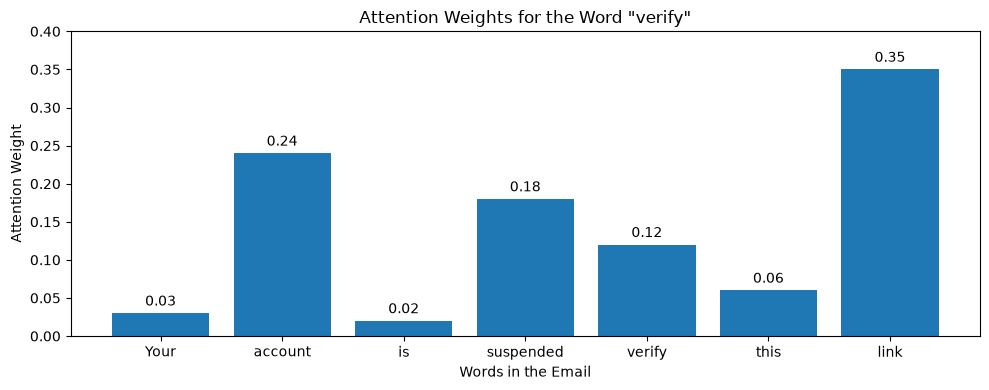

In [1]:
import matplotlib.pyplot as plt

words = ["Your", "account", "is", "suspended", "verify", "this", "link"]
attention_weights = [0.03, 0.24, 0.02, 0.18, 0.12, 0.06, 0.35]

plt.figure(figsize=(10, 4))

bars = plt.bar(words, attention_weights)

plt.title('Attention Weights for the Word "verify"')
plt.xlabel("Words in the Email")
plt.ylabel("Attention Weight")
plt.ylim(0, 0.40)

for bar, weight in zip(bars, attention_weights):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{weight:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> The strongest attention is given to <b style="color:#EA580C;">"link"</b> and <b style="color:#7C3AED;">"account"</b>. This illustrates how attention can connect relevant words even when they are separated in the sequence.</p>
</div>

<div style="background:#FEF2F2;border-left:5px solid #EF4444;border-radius:10px;padding:12px 15px;margin:12px 0;">
  <p style="color:#7F1D1D;line-height:1.8;margin:0;"><b>Key idea:</b> Attention does not treat every word as equally important. It learns which positions are most relevant to each other and gives them stronger attention weights.</p>
</div>

<div style="background:#ECFDF5;border:1px solid #A7F3D0;border-radius:12px;padding:15px 18px;margin:14px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Project connection:</b> In a phishing email, words such as <b style="color:#7C3AED;">urgent</b>, <b style="color:#DB2777;">password</b>, <b style="color:#2563EB;">verify</b>, and <b style="color:#EA580C;">link</b> can reinforce each other's meaning. Attention helps the model connect these clues across the email instead of analyzing each word in isolation.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:13px;padding:16px 19px;margin:21px 0 13px;">
  <h2 style="color:#1D4ED8;margin:0 0 7px;">3. Self-Attention</h2>
  <p style="color:#374151;line-height:1.8;margin:0;">Self-attention applies attention <b style="color:#2563EB;">within the same sequence</b>. Each word examines the other words in the sentence and builds a new representation based on which ones are most relevant to it.</p>
</div>

<div style="background:#FAF5FF;border:1px solid #E9D5FF;border-radius:13px;padding:16px 19px;margin:14px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">Attention vs. Self-Attention</h3>
  <p style="color:#374151;line-height:1.9;margin:0;"><b style="color:#7C3AED;">Attention:</b> The general idea of assigning different importance to different pieces of information.<br><b style="color:#DB2777;">Self-attention:</b> Attention where the elements being compared belong to the <b>same sequence</b>.</p>
</div>

<div style="background:#FFF7ED;border:1px solid #FED7AA;border-radius:13px;padding:16px 19px;margin:14px 0;">
  <h3 style="color:#C2410C;margin:0 0 8px;">One Email, Different Relationships</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">In <b>"Your account is suspended. Verify it using this link."</b>, the word <b style="color:#DB2777;">"it"</b> may focus strongly on <b style="color:#7C3AED;">"account"</b>, while <b style="color:#2563EB;">"verify"</b> may focus on <b style="color:#EA580C;">"link"</b>. Each word can therefore build its own context-aware representation.</p>
</div>

<div style="background:#F0FDFA;border-left:5px solid #14B8A6;border-radius:11px;padding:14px 17px;margin:16px 0 10px;">
  <h3 style="color:#0F766E;margin:0 0 6px;">Visualizing Self-Attention</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">An attention matrix shows how strongly each word can relate to every other word in the same sequence.</p>
</div>

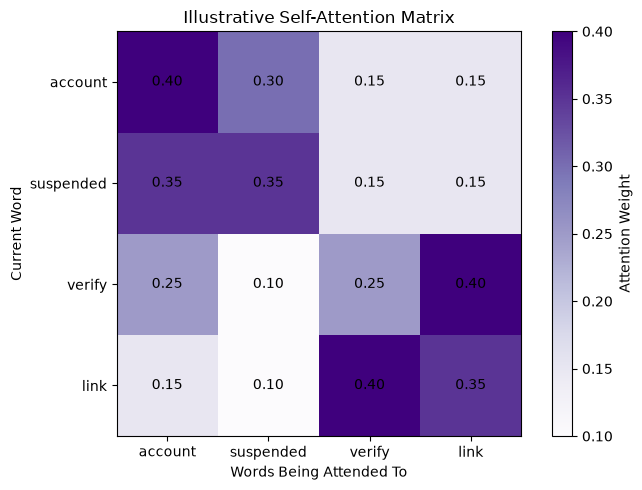

In [2]:
import numpy as np
import matplotlib.pyplot as plt

words = ["account", "suspended", "verify", "link"]

attention_matrix = np.array([
    [0.40, 0.30, 0.15, 0.15],
    [0.35, 0.35, 0.15, 0.15],
    [0.25, 0.10, 0.25, 0.40],
    [0.15, 0.10, 0.40, 0.35]
])

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(attention_matrix, cmap="Purples")

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words)
ax.set_yticklabels(words)

ax.set_xlabel("Words Being Attended To")
ax.set_ylabel("Current Word")
ax.set_title("Illustrative Self-Attention Matrix")

for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{attention_matrix[i, j]:.2f}",
                ha="center", va="center")

plt.colorbar(image, label="Attention Weight")
plt.tight_layout()
plt.show()

<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> Each word distributes its attention differently across the sequence. In this example, <b style="color:#7C3AED;">"verify"</b> gives the highest attention weight to <b style="color:#EA580C;">"link"</b> at <b>0.40</b>, while <b style="color:#2563EB;">"account"</b> gives more attention to <b>"suspended"</b>. This shows how self-attention captures meaningful relationships between words based on context.</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:13px;padding:16px 19px;margin:18px 0 12px;">
  <h3 style="color:#C2410C;margin:0 0 8px;">3.1 Query, Key & Value — Inside Self-Attention</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">To calculate self-attention, each token is represented through three vectors: <b style="color:#7C3AED;">Query (Q)</b>, <b style="color:#2563EB;">Key (K)</b>, and <b style="color:#059669;">Value (V)</b>. Together, they help the model decide which tokens are relevant and what information should be collected from them.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#6D28D9;margin:0 0 9px;">What Do Q, K, and V Mean?</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
  🔎 <b style="color:#7C3AED;">Query (Q)</b> — What information is the current token looking for?<br>
  🔑 <b style="color:#2563EB;">Key (K)</b> — What information does each token contain or represent?<br>
  📦 <b style="color:#059669;">Value (V)</b> — The actual information that can be passed forward if that token receives high attention.
  </p>
</div>

### Scaled Dot-Product Attention

The core self-attention calculation can be summarized as:

$$
\text{Attention}(Q,K,V)
=
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#1D4ED8;margin:0 0 8px;">Reading the Equation Step by Step</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
  <b style="color:#7C3AED;">QKᵀ</b> → measures how strongly tokens are related.<br>
  <b style="color:#EA580C;">√dₖ</b> → scales the scores to keep them numerically stable.<br>
  <b style="color:#EC4899;">Softmax</b> → converts the scores into attention weights.<br>
  <b style="color:#059669;">× V</b> → uses those weights to combine the most relevant information.
  </p>
</div>

<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#047857;margin:0 0 8px;">Phishing Email Example</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">In <b>"Verify your account using this link"</b>, when processing <b style="color:#7C3AED;">"verify"</b>, its Query is compared with the Keys of the other tokens. If <b style="color:#DC2626;">"link"</b> is highly relevant, it receives a larger attention weight, allowing information from its Value to contribute more strongly to the representation of <b>"verify"</b>.</p>
</div>

<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:13px;padding:16px 19px;margin:21px 0 13px;">
  <h2 style="color:#047857;margin:0 0 7px;">4. Transformer Architecture</h2>
  <p style="color:#374151;line-height:1.8;margin:0;">Self-attention provides the key idea, but a <b style="color:#059669;">Transformer</b> turns that idea into a complete architecture. Instead of processing tokens recurrently one after another, Transformers can examine the sequence together and build <b style="color:#2563EB;">context-aware representations</b> using attention.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">From Self-Attention to a Transformer</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
  A Transformer combines several components:<br>
  <b style="color:#7C3AED;">1. Token Embeddings</b> — represent tokens as numerical vectors.<br>
  <b style="color:#2563EB;">2. Positional Information</b> — tells the model where tokens appear in the sequence.<br>
  <b style="color:#EC4899;">3. Self-Attention</b> — captures relationships between tokens.<br>
  <b style="color:#EA580C;">4. Feed-Forward Network</b> — further transforms the information learned by attention.
  </p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:16px 0 10px;">
  <h3 style="color:#1D4ED8;margin:0 0 6px;">Visualizing the Transformer Flow</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">The following simplified flow shows how text moves through the main Transformer components.</p>
</div>

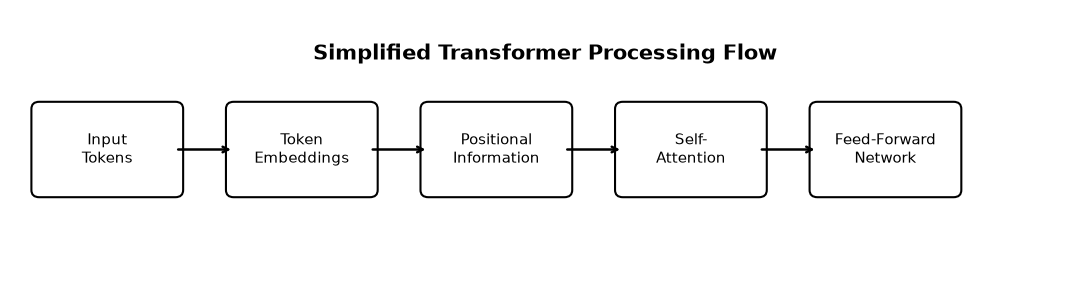

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 3))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3)
ax.axis("off")

steps = [
    ("Input\nTokens", 0.3),
    ("Token\nEmbeddings", 2.3),
    ("Positional\nInformation", 4.3),
    ("Self-\nAttention", 6.3),
    ("Feed-Forward\nNetwork", 8.3)
]

for text, x in steps:
    box = FancyBboxPatch(
        (x, 1), 1.4, 0.9,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        fill=False
    )
    ax.add_patch(box)
    ax.text(x + 0.7, 1.45, text, ha="center", va="center", fontsize=11)

for i in range(len(steps) - 1):
    start = steps[i][1] + 1.4
    end = steps[i + 1][1]
    ax.annotate(
        "",
        xy=(end, 1.45),
        xytext=(start, 1.45),
        arrowprops=dict(arrowstyle="->", lw=1.8)
    )

ax.text(
    5.5, 2.45,
    "Simplified Transformer Processing Flow",
    ha="center", fontsize=15, fontweight="bold"
)

plt.tight_layout()
plt.show()

<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> The Transformer does not depend on a recurrent hidden state moving from one token to the next. Instead, token representations receive <b style="color:#2563EB;">positional information</b>, interact through <b style="color:#7C3AED;">self-attention</b>, and are further processed by a <b style="color:#EA580C;">feed-forward network</b>.</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:13px;padding:16px 19px;margin:21px 0 13px;">
  <h2 style="color:#C2410C;margin:0 0 7px;">4.1 Positional Encoding</h2>
  <p style="color:#374151;line-height:1.8;margin:0;">Self-attention can examine tokens together, but by itself it does not provide the model with their <b style="color:#EA580C;">sequence order</b>. Transformers therefore add <b style="color:#7C3AED;">positional information</b> to token representations so the model can distinguish where each token appears in the sequence.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">Why Does Position Matter?</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">
  Consider <b style="color:#2563EB;">"User reports phishing"</b> and <b style="color:#EC4899;">"Phishing reports user"</b>. The same words appear in both sequences, but changing their positions changes the meaning. Positional information helps the Transformer preserve this order while still benefiting from parallel processing.
  </p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#1D4ED8;margin:0 0 8px;">How Is Position Added?</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
  Each token first receives a <b style="color:#7C3AED;">Token Embedding</b> that represents its meaning. A <b style="color:#EA580C;">Positional Encoding</b> represents its position in the sequence. These two representations are combined before the information enters the Transformer layers.<br><br>
  <b style="color:#2563EB;">Final Input Representation = Token Embedding + Positional Information</b>
  </p>
</div>

<div style="background:#FEF2F2;border:1px solid #FECACA;border-left:5px solid #EF4444;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#DC2626;">Key Idea:</b> Attention tells the Transformer <b>which tokens are related</b>, while positional information tells it <b>where those tokens occur</b> in the sequence.</p>
</div>

<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:13px;padding:16px 19px;margin:15px 0;">
  <h3 style="color:#047857;margin:0 0 8px;">4.2 Project Connection — Phishing Email Detection</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">
  In phishing detection, an email may contain important clues in <b style="color:#7C3AED;">different positions</b>. Words such as <b style="color:#DC2626;">"urgent"</b>, <b style="color:#2563EB;">"account"</b>, <b style="color:#EA580C;">"verify"</b>, and <b style="color:#059669;">"link"</b> may appear far apart. A Transformer can use <b style="color:#7C3AED;">self-attention</b> to connect these clues directly while <b style="color:#EA580C;">positional information</b> preserves their order, helping the model understand the email as a complete context rather than isolated words.
  </p>
</div>

<div style="background:#EFF6FF;border-radius:11px;padding:14px 17px;margin:12px 0;color:#1E3A8A;line-height:1.8;">
  <b>Next Question:</b> Do we need to train a Transformer from scratch to detect phishing emails, or can we start from a model that already understands language?
</div>

<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:13px;padding:16px 19px;margin:21px 0 13px;">
  <h2 style="color:#BE185D;margin:0 0 7px;">5. Pre-trained Transformers</h2>
  <p style="color:#374151;line-height:1.8;margin:0;">Training a Transformer from scratch requires a large amount of text, computing power, and time. Instead, we can use a <b style="color:#EC4899;">pre-trained Transformer</b> that has already learned general language patterns, then adapt it to a specific task such as <b style="color:#DC2626;">phishing email classification</b>.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#1D4ED8;margin:0 0 8px;">The Main Idea — Transfer Learning</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">A pre-trained model already understands many general language patterns. Instead of starting with random knowledge, we reuse what it has learned and <b style="color:#7C3AED;">fine-tune</b> it for our target task. This is similar to transfer learning in computer vision.</p>
</div>

<div style="background:#FAF5FF;border-radius:14px;padding:18px 21px;margin:14px 0;">
  <h3 style="color:#7E22CE;margin:0 0 13px;">Popular Pre-trained Transformers</h3>

  <p style="color:#374151;line-height:1.8;"><b style="color:#2563EB;">BERT</b> — An encoder-based Transformer designed to build rich contextual representations of text. It is widely used for understanding tasks such as text classification.</p>

  <p style="color:#374151;line-height:1.8;"><b style="color:#059669;">DistilBERT</b> — A smaller and faster version of BERT created through knowledge distillation. It preserves the main language-understanding strengths of BERT while requiring fewer computational resources.</p>

  <p style="color:#374151;line-height:1.8;margin-bottom:0;"><b style="color:#EA580C;">GPT-2</b> — A decoder-based autoregressive Transformer designed mainly to predict the next token, making it especially suitable for text generation.</p>
</div>

<div style="background:#F8FAFC;border-left:5px solid #6366F1;border-radius:13px;padding:16px 19px;margin:16px 0 12px;">
  <h3 style="color:#4338CA;margin:0 0 10px;">BERT vs DistilBERT vs GPT-2</h3>
  <table style="width:100%;border-collapse:collapse;color:#374151;text-align:left;">
    <tr style="background:#EEF2FF;">
      <th style="padding:10px;">Model</th>
      <th style="padding:10px;">Architecture</th>
      <th style="padding:10px;">Main Strength</th>
      <th style="padding:10px;">Typical Use</th>
    </tr>
    <tr><td style="padding:10px;"><b style="color:#2563EB;">BERT</b></td><td style="padding:10px;">Encoder</td><td style="padding:10px;">Context understanding</td><td style="padding:10px;">Classification & understanding</td></tr>
    <tr style="background:#F8FAFC;"><td style="padding:10px;"><b style="color:#059669;">DistilBERT</b></td><td style="padding:10px;">Encoder</td><td style="padding:10px;">Smaller & faster</td><td style="padding:10px;">Efficient text classification</td></tr>
    <tr><td style="padding:10px;"><b style="color:#EA580C;">GPT-2</b></td><td style="padding:10px;">Decoder</td><td style="padding:10px;">Next-token prediction</td><td style="padding:10px;">Text generation</td></tr>
  </table>
</div>

<div style="background:#ECFDF5;border:1px solid #A7F3D0;border-left:5px solid #10B981;border-radius:13px;padding:16px 19px;margin:13px 0;">
  <h3 style="color:#047857;margin:0 0 8px;">🏆 Why DistilBERT for Our Phishing Detector?</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">Our task is <b style="color:#7C3AED;">text classification</b>, not text generation. DistilBERT is an encoder-based model designed for language understanding while being more computationally efficient than full BERT. This makes it a practical choice for classifying emails as <b style="color:#059669;">Legitimate</b> or <b style="color:#DC2626;">Phishing</b>.</p>
</div>

<div style="background:#FEF2F2;border-left:5px solid #EF4444;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#DC2626;">Key Idea:</b> The best Transformer depends on the task. For our project, we need to <b>understand and classify</b> an email rather than generate new text, making <b style="color:#059669;">DistilBERT</b> a suitable core model.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:13px;padding:16px 19px;margin:21px 0 13px;">
  <h2 style="color:#1D4ED8;margin:0 0 7px;">6. Hugging Face Transformers</h2>
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#2563EB;">Hugging Face Transformers</b> provides ready-to-use pre-trained Transformer models and tools. Instead of implementing BERT or DistilBERT from scratch, we can load a pre-trained model, tokenize text, perform inference, and fine-tune it for a specific task.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">How Does the Hugging Face Workflow Work?</h3>
  <p style="color:#374151;line-height:2;margin:0;">
  <b style="color:#EA580C;">1. Raw Text</b> → The original sentence or email.<br>
  <b style="color:#7C3AED;">2. Tokenizer</b> → Converts text into tokens and numerical IDs.<br>
  <b style="color:#2563EB;">3. Pre-trained Transformer</b> → Builds contextual representations of the tokens.<br>
  <b style="color:#EC4899;">4. Task Head</b> → Produces the prediction for a task such as classification.<br>
  <b style="color:#059669;">5. Output</b> → Returns the predicted class and score.
  </p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#C2410C;margin:0 0 8px;">The pipeline() API</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">For simple inference, Hugging Face provides the <b style="color:#7C3AED;">pipeline()</b> API. It combines preprocessing, the pre-trained model, and post-processing into one simple interface. For example, a sentiment-analysis pipeline can classify a sentence without manually building a Transformer.</p>
</div>

<div style="background:linear-gradient(120deg,#4B3FD6,#7C3AED,#D946A8);padding:22px 27px;border-radius:17px;color:white;margin-top:22px;">
  <h2 style="margin:0 0 8px;">Theory Complete ✓</h2>
  <p style="font-size:17px;line-height:1.7;margin:0;">We now understand why Transformers replaced recurrent processing, how self-attention works, and how pre-trained models can be reused. Next, we will turn these ideas into a real <b>Phishing Email Detection</b> experiment.</p>
</div>

<div style="background:linear-gradient(120deg,#0F766E,#2563EB,#7C3AED);padding:26px 30px;border-radius:19px;color:white;margin-top:24px;">
  <p style="font-size:15px;font-weight:bold;letter-spacing:2px;margin:0 0 10px;">WEEK 7 • DAY 4 • PRACTICAL LAB</p>
  <h1 style="font-size:34px;margin:0 0 9px;">Hands-On — Phishing Email Detection</h1>
  <p style="font-size:17px;line-height:1.7;margin:0;">Applying pre-trained Transformers and DistilBERT to build a real-world phishing email classification workflow.</p>
</div>

<div style="background:#F5F3FF;border-left:6px solid #8B5CF6;border-radius:13px;padding:17px 20px;margin:20px 0 13px;">
  <h2 style="color:#6D28D9;margin:0 0 8px;">Step 1 — Test a Pre-trained Transformer</h2>
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#7C3AED;">Task:</b> Load a pre-trained Transformer using the Hugging Face <b>pipeline()</b> API and run it on sample text to observe how a ready-to-use Transformer performs inference.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#1D4ED8;margin:0 0 8px;">Before We Start</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">
  Before working with our phishing dataset, we first want to see how a <b style="color:#7C3AED;">pre-trained Transformer</b> behaves out of the box. We will use Hugging Face <b style="color:#2563EB;">pipeline()</b> to load a ready-to-use sentiment model, then test it on a few sample sentences and inspect its predictions and confidence scores.
  </p>
</div>

In [4]:
!pip install -q transformers

In [5]:
!pip install -q torch

In [6]:
import torch

print(torch.__version__)
print("PyTorch is working!")

2.13.0+cpu
PyTorch is working!


<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:13px 16px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;">
  Now that the Transformers library is installed, we can load a pre-trained model through the <b style="color:#7C3AED;">pipeline()</b> interface. This hides the internal tokenization and model setup, allowing us to focus first on the final inference result.
  </p>
</div>

In [7]:

from transformers import pipeline

sentiment_classifier = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [8]:
sample_texts = [
    "I really enjoyed learning about Transformers today!",
    "This experience was terrible and frustrating."
]

results = sentiment_classifier(sample_texts)

for text, result in zip(sample_texts, results):
    print("Text:", text)
    print("Prediction:", result["label"])
    print("Confidence:", round(result["score"], 4))
    print("-" * 50)

Text: I really enjoyed learning about Transformers today!
Prediction: POSITIVE
Confidence: 0.9998
--------------------------------------------------
Text: This experience was terrible and frustrating.
Prediction: NEGATIVE
Confidence: 0.9994
--------------------------------------------------


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> The pre-trained Transformer correctly classified both sample sentences with very high confidence. The positive sentence was predicted as <b style="color:#059669;">POSITIVE</b> with a confidence of <b>0.9998</b>, while the negative sentence was predicted as <b style="color:#DC2626;">NEGATIVE</b> with a confidence of <b>0.9994</b>. This demonstrates that a pre-trained Transformer can perform meaningful text inference immediately, without training a new model from scratch.</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#C2410C;">But there is a limitation:</b> This model was fine-tuned for <b>sentiment analysis</b>, not phishing detection. To solve our cybersecurity problem, we need to adapt a Transformer to emails labeled specifically as <b style="color:#059669;">Legitimate</b> or <b style="color:#DC2626;">Phishing</b>.</p>
</div>

<div style="background:#EFF6FF;border-left:6px solid #3B82F6;border-radius:13px;padding:17px 20px;margin:22px 0 13px;">
 <h2 style="color:#1D4ED8;margin:0 0 8px;">Step 2 — Apply the Transformer to Project Data</h2>
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#2563EB;">Task:</b> Prepare the phishing email dataset, fine-tune DistilBERT for binary classification, evaluate its performance, and connect the results to the Day 3 LSTM experiment.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">From General Language to Cybersecurity Data</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">The previous experiment showed that a pre-trained Transformer already understands general language patterns. Our goal is now different: instead of detecting sentiment, we want to recognize <b style="color:#DC2626;">phishing behavior</b>. Before adapting DistilBERT to this task, we first need to understand the emails and labels contained in our dataset.</p>
</div>

In [9]:
import pandas as pd

df = pd.read_csv("AVN_Basic.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (60000, 7)


,subject,receiver,sender,label,body,urls,date
0,Internet Explorer 7,user8.2-ext1@gvc.ceas-challenge.cc,user8.2-ext1@gvc.ceas-challenge.cc,1,\n\n\n\n\n\n\n\n\n\n\n\nDownload the latest ve...,0,"Wed, 06 Aug 2008 09:20:36 -0400"
1,Show her your real size,user2.1@gvc.ceas-challenge.cc,Thomas <>,1,Stop feeling unfulfilled about your lovemaking...,1,"Fri, 08 Aug 2008 13:48:06 +0200"
2,No Subject,Unknown Receiver,Unknown Sender,1,Do you want 750 anytime any network mins 150 t...,0,Unknown Date
3,100mg x 60 pills US $ 2.17 Per Pill price,user2.7@gvc.ceas-challenge.cc,Eugenia French <disallow@usa-zero.com>,1,\nPrice for 100mg x 90 pills US $ 1.78 Per Pil...,1,"Wed, 06 Aug 2008 12:39:27 +0700"
4,Your Weekly Movie Showtimes from Amazon.com,user6@gvc.ceas-challenge.cc,"""Amazon.com"" <esbezaroa@amazon.com>",0,"\n\n Showtimes for February 15th, 2008 near...",1,"Tue, 05 Aug 2008 21:07:53 -0800"


<div style="background:#F0FDF4;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Initial Observation:</b> The dataset contains both <b style="color:#7C3AED;">email text</b> and additional metadata. The <b>subject</b> and <b>body</b> columns provide the main textual content that can be used by a Transformer, while columns such as sender, receiver, URLs, and date provide additional email information. Before selecting the final model input, we need to inspect the dataset size, label distribution, missing values, and duplicates.</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#C2410C;margin:0 0 7px;">Dataset Overview</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">A few sample emails are not enough to understand the full dataset. We will now inspect its dimensions, column types, class distribution, missing values, and duplicate records before deciding how the data should be prepared.</p>
</div>

In [10]:
print("Dataset Shape:", df.shape)

print("\nColumn Information:")
df.info()

print("\nLabel Distribution:")
print(df["label"].value_counts().sort_index())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (60000, 7)

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   59936 non-null  str  
 1   receiver  59939 non-null  str  
 2   sender    60000 non-null  str  
 3   label     60000 non-null  int64
 4   body      59949 non-null  str  
 5   urls      60000 non-null  str  
 6   date      59943 non-null  str  
dtypes: int64(1), str(6)
memory usage: 3.2 MB

Label Distribution:
label
0    31122
1    28476
2      402
Name: count, dtype: int64

Missing Values:
subject     64
receiver    61
sender       0
label        0
body        51
urls         0
date        57
dtype: int64

Duplicate Rows: 5988


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:15px 18px;margin:12px 0;">
  <h3 style="color:#15803D;margin:0 0 8px;">Dataset Inspection — Observation</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
  The dataset contains <b style="color:#2563EB;">60,000 emails</b> and <b>7 columns</b>. The two main classes are relatively balanced, with <b style="color:#059669;">31,122 samples of class 0</b> and <b style="color:#DC2626;">28,476 samples of class 1</b>. A small third class, <b style="color:#EA580C;">class 2</b>, contains only <b>402 samples</b>. The dataset also contains a small number of missing values and <b style="color:#7C3AED;">5,988 duplicate rows</b>. Therefore, the data should be cleaned before preparing it for Transformer training.
  </p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#C2410C;margin:0 0 8px;">Understanding the Target Labels</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
  <b style="color:#059669;">Label 0 — Legitimate:</b> Normal non-phishing emails.<br>
  <b style="color:#DC2626;">Label 1 — Phishing:</b> Emails representing phishing or malicious behavior.<br>
  <b style="color:#EA580C;">Label 2 — Garbage:</b> Noise intentionally included in the dataset.<br><br>
  Since our application is designed as a <b style="color:#7C3AED;">binary phishing detector</b>, class 2 will be removed before model training.
  </p>
</div>

<div style="background:#ECFDF5;border-left:6px solid #10B981;border-radius:13px;padding:17px 20px;margin:22px 0 13px;">
  <h2 style="color:#047857;margin:0 0 8px;">  Clean & Prepare the Email Data</h2>
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#059669;">Task:</b> Prepare the dataset for binary phishing classification by removing irrelevant noise, duplicate records, and unusable text samples, then construct the final text input for DistilBERT.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">What Needs to Be Cleaned?</h3>
  <p style="color:#374151;line-height:1.9;margin:0;">
  Our inspection revealed three issues that matter for training. First, <b style="color:#EA580C;">class 2</b> represents garbage/noise and does not belong to our binary task. Second, the dataset contains <b style="color:#7C3AED;">5,988 duplicate rows</b>, which could cause repeated examples to influence the model unnecessarily. Finally, some emails have missing textual fields. We will address these issues before creating the final Transformer input.
  </p>
</div>

In [11]:
df_clean = df[df["label"].isin([0, 1])].copy()

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Original Shape:", df.shape)
print("Shape After Removing Class 2 and Duplicates:", df_clean.shape)

print("\nLabel Distribution:")
print(df_clean["label"].value_counts().sort_index())

Original Shape: (60000, 7)
Shape After Removing Class 2 and Duplicates: (53611, 7)

Label Distribution:
label
0    25988
1    27623
Name: count, dtype: int64


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> After removing the garbage class and duplicate records, the dataset was reduced from <b style="color:#2563EB;">60,000</b> to <b style="color:#7C3AED;">53,611 emails</b>. The remaining binary classes are still well balanced, with <b style="color:#059669;">25,988 legitimate</b> and <b style="color:#DC2626;">27,623 phishing</b> emails. This provides a suitable class distribution for our binary classification task.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <h3 style="color:#1D4ED8;margin:0 0 8px;">Building the Transformer Input</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">Phishing clues may appear in both the <b style="color:#7C3AED;">subject</b> and the <b style="color:#EC4899;">email body</b>. Instead of using only one field, we will combine them into a single <b style="color:#2563EB;">text</b> input. Missing values will be replaced with empty strings so that useful emails are not removed unnecessarily.</p>
</div>

In [12]:
df_clean["subject"] = df_clean["subject"].fillna("")
df_clean["body"] = df_clean["body"].fillna("")

df_clean["text"] = (
    df_clean["subject"].str.strip()
    + " "
    + df_clean["body"].str.strip()
).str.strip()

print("Missing Text Values:", df_clean["text"].isnull().sum())
print("Empty Text Samples:", (df_clean["text"] == "").sum())

display(df_clean[["text", "label"]].head())

Missing Text Values: 0
Empty Text Samples: 1


,text,label
0,Internet Explorer 7 Download the latest versio...,1
1,Show her your real size Stop feeling unfulfill...,1
2,No Subject Do you want 750 anytime any network...,1
3,100mg x 60 pills US $ 2.17 Per Pill price Pric...,1
4,Your Weekly Movie Showtimes from Amazon.com Sh...,0


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> The <b style="color:#7C3AED;">subject</b> and <b style="color:#EC4899;">body</b> were successfully combined into one <b style="color:#2563EB;">text</b> feature while preserving the correct label for each email. After filling missing textual fields, the final input contains <b style="color:#059669;">0 missing text values</b> and <b style="color:#059669;">0 empty text samples</b>. This means every remaining email now has usable textual content ready for Transformer tokenization and classification.</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:14px 0;">
  <h3 style="color:#C2410C;margin:0 0 8px;">Preparing the Data for Training</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">Now that every email has a usable text representation, we need to separate the data into <b style="color:#7C3AED;">training</b> and <b style="color:#2563EB;">testing</b> sets. The training set will be used to adapt DistilBERT to phishing detection, while the test set will be kept unseen until evaluation.</p>
</div>

In [13]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_clean[["text", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=df_clean["label"]
)

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

print("\nTraining Label Distribution:")
print(train_df["label"].value_counts())

print("\nTesting Label Distribution:")
print(test_df["label"].value_counts())

Training Shape: (42888, 2)
Testing Shape: (10723, 2)

Training Label Distribution:
label
1    22098
0    20790
Name: count, dtype: int64

Testing Label Distribution:
label
1    5525
0    5198
Name: count, dtype: int64


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> The cleaned dataset was split into <b style="color:#7C3AED;">42,888 training emails</b> and <b style="color:#2563EB;">10,723 testing emails</b>. Using <b style="color:#EA580C;">stratified splitting</b> preserved the class proportions in both sets, with phishing and legitimate emails remaining closely balanced. This ensures that the model will train and later be evaluated on representative class distributions.</p>
</div>

In [14]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Device: CPU")

CUDA Available: False
Device: CPU


<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:14px 0;">
  <h3 style="color:#C2410C;margin:0 0 8px;">Adapting the Experiment to CPU</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">Because no CUDA-enabled GPU is available, fine-tuning DistilBERT on the full dataset would be computationally expensive. To keep the experiment practical while preserving both classes, we will use a <b style="color:#7C3AED;">stratified sample</b> for training and evaluation.</p>
</div>

In [15]:
train_sample, _ = train_test_split(
    train_df,
    train_size=4000,
    random_state=42,
    stratify=train_df["label"]
)

test_sample, _ = train_test_split(
    test_df,
    train_size=1000,
    random_state=42,
    stratify=test_df["label"]
)

print("Training Sample Shape:", train_sample.shape)
print("Testing Sample Shape:", test_sample.shape)

print("\nTraining Sample Distribution:")
print(train_sample["label"].value_counts())

print("\nTesting Sample Distribution:")
print(test_sample["label"].value_counts())

Training Sample Shape: (4000, 2)
Testing Sample Shape: (1000, 2)

Training Sample Distribution:
label
1    2061
0    1939
Name: count, dtype: int64

Testing Sample Distribution:
label
1    515
0    485
Name: count, dtype: int64


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> A CPU-friendly subset was created with <b style="color:#7C3AED;">4,000 training emails</b> and <b style="color:#2563EB;">1,000 testing emails</b>. Stratified sampling preserved the class balance: the training subset contains <b>2,061 phishing</b> and <b>1,939 legitimate</b> emails, while the test subset contains <b>515 phishing</b> and <b>485 legitimate</b> emails. This provides a representative but computationally manageable dataset for the DistilBERT experiment.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:14px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">Tokenizing the Emails with DistilBERT</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">DistilBERT cannot process raw email strings directly. Its <b style="color:#7C3AED;">tokenizer</b> converts each email into tokens and then into numerical IDs understood by the model. Long emails will be <b style="color:#EA580C;">truncated</b> to a fixed maximum length, while shorter emails will be <b style="color:#2563EB;">padded</b> so they can be processed together.</p>
</div>

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(
    train_sample["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_sample["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Training Emails Tokenized:", len(train_encodings["input_ids"]))
print("Testing Emails Tokenized:", len(test_encodings["input_ids"]))
print("Tokens per Email:", len(train_encodings["input_ids"][0]))

Training Emails Tokenized: 4000
Testing Emails Tokenized: 1000
Tokens per Email: 128


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> All <b style="color:#7C3AED;">4,000 training emails</b> and <b style="color:#2563EB;">1,000 testing emails</b> were successfully tokenized. Each email was represented using a fixed sequence length of <b style="color:#EA580C;">128 tokens</b>, allowing the inputs to be processed consistently while keeping the experiment lightweight enough for CPU-based training.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:14px 0;">
  <h3 style="color:#1D4ED8;margin:0 0 8px;">Preparing DistilBERT for Binary Classification</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">We will now load a pre-trained <b style="color:#7C3AED;">DistilBERT</b> model and attach a classification head with <b style="color:#059669;">2 output classes</b>: Legitimate and Phishing. The tokenized emails and labels will also be converted into a PyTorch dataset format for training.</p>
</div>

In [17]:
import torch
from torch.utils.data import Dataset
from transformers import AutoModelForSequenceClassification

class EmailDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(
    train_encodings,
    train_sample["label"]
)

test_dataset = EmailDataset(
    test_encodings,
    test_sample["label"]
)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Training Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))
print("Model Ready for Binary Classification")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Samples: 4000
Testing Samples: 1000
Model Ready for Binary Classification


<div style="background:#F0FDF4;border:1px solid #BBF7D0;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:12px 0;">
  <p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Observation:</b> DistilBERT was successfully loaded for <b style="color:#7C3AED;">binary sequence classification</b>. The newly initialized classification layers are expected because the original pre-trained checkpoint was not trained specifically for phishing detection. The model is now ready to learn the difference between <b style="color:#059669;">Legitimate</b> and <b style="color:#DC2626;">Phishing</b> emails using our labeled dataset.</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:14px 0;">
  <h3 style="color:#C2410C;margin:0 0 8px;">Fine-Tuning DistilBERT</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">The pre-trained DistilBERT model already contains general language knowledge, but its new classification head has not yet learned our phishing task. We will now <b style="color:#7C3AED;">fine-tune</b> the model on the labeled email samples. Since training is running on <b style="color:#EA580C;">CPU</b>, the experiment uses one epoch and a small batch size to keep the computational cost manageable.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:14px 0;">
  <h3 style="color:#6D28D9;margin:0 0 8px;">Training Configuration</h3>
  <p style="color:#374151;line-height:1.8;margin:0;">To keep fine-tuning practical on CPU, the model will train for <b style="color:#EA580C;">1 epoch</b> using a small <b style="color:#2563EB;">batch size of 8</b>. The objective is to demonstrate how a pre-trained Transformer can be adapted to our phishing classification task without requiring full-scale GPU training.</p>
</div>

In [19]:
!pip install -q -U "accelerate>=1.1.0"

In [20]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./distilbert_phishing_results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print("Trainer Ready")

Trainer Ready


In [22]:
train_result = trainer.train()

c:\Users\Bisan\miniconda3\envs\binx-ai\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.469315
100,0.169947
150,0.154846
200,0.176905
250,0.108959
300,0.108553
350,0.104020
400,0.131952
450,0.120491
500,0.095421


<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:14px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Observation:</b> The training loss decreased from approximately <b>0.469</b> at step 50 to <b>0.095</b> at step 500. This clear downward trend indicates that DistilBERT successfully learned useful patterns from the phishing email training data during the single fine-tuning epoch. Small fluctuations between some steps are normal during mini-batch training.</p>
</div>

<div style="background:#EFF6FF;border-left:5px solid #2563EB;border-radius:11px;padding:14px 17px;margin:14px 0;">
<h3 style="color:#1D4ED8;margin:0 0 8px;">Evaluate the Fine-Tuned Transformer</h3>
<p style="color:#374151;line-height:1.8;margin:0;">Training loss tells us how well the model learned the training examples, but the real test is whether it can generalize to unseen emails. We will now evaluate DistilBERT on the held-out test subset and calculate classification metrics for phishing detection.</p>
</div>

In [23]:
predictions = trainer.predict(test_dataset)

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:14px 0;">
<h3 style="color:#6D28D9;margin:0 0 8px;">Classification Performance</h3>
<p style="color:#374151;line-height:1.8;margin:0;">To measure how well the fine-tuned Transformer detects unseen phishing emails, we calculate <b style="color:#2563EB;">Accuracy</b>, <b style="color:#059669;">Precision</b>, <b style="color:#EA580C;">Recall</b>, and <b style="color:#7C3AED;">F1-score</b>. These metrics provide a more complete evaluation than training loss alone.</p>
</div>

In [24]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9610
Precision: 0.9741
Recall   : 0.9495
F1-score : 0.9617


<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:14px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Observation:</b> The fine-tuned DistilBERT achieved <b>96.10% accuracy</b> and an <b>F1-score of 96.17%</b> on unseen test emails. The high <b>97.41% precision</b> shows that most emails predicted as phishing were truly phishing, while the <b>94.95% recall</b> indicates that the model successfully detected most phishing emails. These results demonstrate that the pre-trained Transformer adapted effectively to the phishing detection task even with a CPU-friendly training subset.</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:14px 0;">
<h3 style="color:#C2410C;margin:0 0 8px;">Where Did the Model Make Mistakes?</h3>
<p style="color:#374151;line-height:1.8;margin:0;">The overall metrics are strong, but cybersecurity decisions also depend on the <b style="color:#DC2626;">type of error</b>. A confusion matrix helps us distinguish between legitimate emails incorrectly flagged as phishing and phishing emails that were incorrectly allowed as legitimate.</p>
</div>

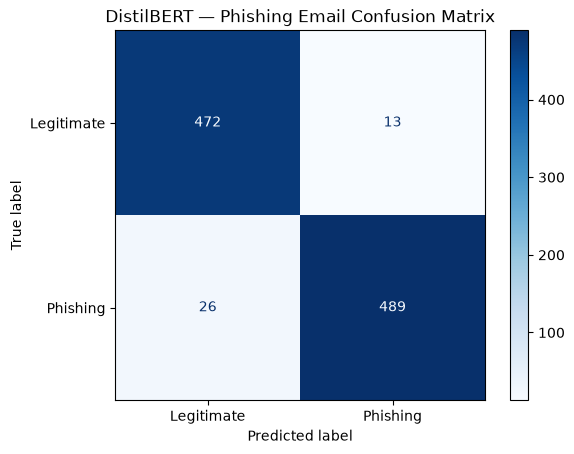

[[472  13]
 [ 26 489]]


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("DistilBERT — Phishing Email Confusion Matrix")
plt.show()

print(cm)

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:14px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#C2410C;">Observation:</b> The model correctly classified <b>472 legitimate emails</b> and detected <b>489 phishing emails</b>. Only <b>13 legitimate emails</b> were incorrectly flagged as phishing, while <b style="color:#DC2626;">26 phishing emails</b> were incorrectly classified as legitimate. These false negatives are particularly important in cybersecurity because they represent malicious emails that could bypass the detector. Overall, the confusion matrix confirms the model's strong performance while highlighting false-negative reduction as an important area for future improvement.</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:14px 0;">
<h3 style="color:#6D28D9;margin:0 0 8px;">Transformer vs. Day 3 LSTM</h3>
<p style="color:#374151;line-height:1.8;margin:0;">Day 3 used an <b style="color:#2563EB;">LSTM</b> for ECG sequence classification, while Day 4 uses <b style="color:#7C3AED;">DistilBERT</b> for phishing email classification. Their results are reported together to connect the two experiments, but they should <b style="color:#DC2626;">not be interpreted as a direct performance comparison</b> because the models were evaluated on different datasets, modalities, and prediction tasks.</p>
</div>

,Model,Task,Accuracy
0,Day 3 LSTM,ECG Classification,92.36
1,Day 4 DistilBERT,Phishing Email Detection,96.10


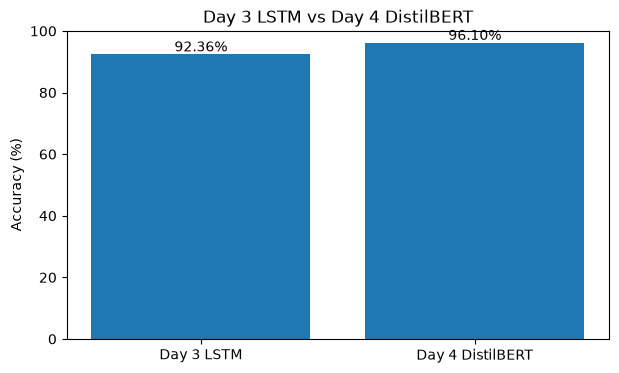

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": ["Day 3 LSTM", "Day 4 DistilBERT"],
    "Task": ["ECG Classification", "Phishing Email Detection"],
    "Accuracy": [92.36, 96.10]
})

display(comparison)

plt.figure(figsize=(7, 4))
bars = plt.bar(comparison["Model"], comparison["Accuracy"])

plt.ylabel("Accuracy (%)")
plt.title("Day 3 LSTM vs Day 4 DistilBERT")
plt.ylim(0, 100)

for bar, value in zip(bars, comparison["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:14px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Observation:</b> DistilBERT achieved <b>96.10% accuracy</b>, while the Day 3 LSTM achieved <b>92.36%</b>. However, the higher DistilBERT accuracy does not mean that it is universally better than the LSTM, because the two models were evaluated on <b>different datasets and different tasks</b>. The LSTM processed ECG sequences, whereas DistilBERT classified phishing email text. Therefore, this comparison summarizes the outcomes of the two experiments rather than providing a direct model benchmark.</p>
</div>

<div style="background:linear-gradient(135deg,#4C1D95,#7C3AED);border-radius:13px;padding:17px 20px;margin:18px 0;">
<h2 style="color:white;margin:0;">Hands-On Step 3 — Attention vs. RNN Memory</h2>
<p style="color:#EDE9FE;margin:7px 0 0;">How does a Transformer handle context differently from a recurrent network?</p>
</div>

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:11px;padding:14px 17px;margin:14px 0;">
<p style="color:#374151;line-height:1.9;margin:0;">An <b style="color:#2563EB;">RNN</b> processes a sequence step by step and carries information forward through its hidden state, meaning that earlier information must pass through multiple sequential steps before influencing later words. This can make long-range relationships harder to preserve and prevents efficient parallel processing. In contrast, a Transformer uses <b style="color:#7C3AED;">self-attention</b>, allowing each token to directly examine and assign importance to other tokens in the sequence. For phishing detection, this means DistilBERT can directly connect distant clues such as <b style="color:#DC2626;">“account suspended”</b> and <b style="color:#DC2626;">“click this link”</b> without depending on information being carried through every intermediate word.</p>
</div>

<div style="background:linear-gradient(135deg,#064E3B,#059669);border-radius:13px;padding:17px 20px;margin:18px 0;">
<h2 style="color:white;margin:0;">Hands-On Step 4 — Choosing the Core Architecture</h2>
<p style="color:#D1FAE5;margin:7px 0 0;">Which architecture should power the phishing email detection application?</p>
</div>

<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:14px 0;">
<h3 style="color:#047857;margin:0 0 8px;">Core Model — DistilBERT Transformer</h3>
<p style="color:#374151;line-height:1.9;margin:0;">For the phishing email detection project, <b style="color:#7C3AED;">DistilBERT</b> is selected as the core architecture. Unlike an LSTM that processes sequences recurrently, DistilBERT uses <b style="color:#2563EB;">self-attention</b> to capture relationships between words across an email and starts with pre-trained language knowledge that can be adapted to phishing classification. It achieved <b style="color:#059669;">96.10% accuracy</b> and an <b style="color:#059669;">F1-score of 96.17%</b> on the held-out test sample. Its smaller and faster design compared with full BERT also makes it a practical choice for a future phishing detection application.</p>
</div>

<div style="background:#EFF6FF;border:1px solid #93C5FD;border-radius:12px;padding:16px 18px;margin:14px 0;">
<h3 style="color:#1D4ED8;margin:0 0 12px;">From Model to Application</h3>
<p style="color:#374151;line-height:1.8;margin:0 0 12px;">The trained Transformer can be integrated into a simple AI-powered phishing detection application:</p>

<div style="text-align:center;font-size:16px;font-weight:600;line-height:2.2;">
<span style="color:#1D4ED8;">User Email</span> → 
<span style="color:#7C3AED;">DistilBERT Tokenizer</span> → 
<span style="color:#7C3AED;">Fine-Tuned DistilBERT</span> → 
<span style="color:#EA580C;">Classification</span> → 
<span style="color:#DC2626;">Phishing</span> / 
<span style="color:#059669;">Legitimate</span>
</div>

<p style="color:#374151;line-height:1.8;margin:12px 0 0;">The application could allow a user to paste an email and receive a predicted class with a confidence score, providing an immediate warning when suspicious phishing behavior is detected.</p>
</div>

<div style="background:linear-gradient(135deg,#7C2D12,#EA580C);border-radius:13px;padding:17px 20px;margin:20px 0 14px;">
<h2 style="color:white;margin:0;">Project Application Prototype</h2>
<p style="color:#FFEDD5;margin:7px 0 0;">Can our fine-tuned DistilBERT classify a completely new email?</p>
</div>

<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:12px 0;">
<p style="color:#374151;line-height:1.8;margin:0;">Training metrics show how the model performs on the test dataset, but a real application must also accept <b style="color:#EA580C;">new user input</b>. To simulate this behavior, we will create a small prediction function that receives raw email text, tokenizes it using the same DistilBERT tokenizer, passes it through the fine-tuned model, and returns the predicted class together with a <b style="color:#7C3AED;">confidence score</b>.</p>
</div>

In [27]:
import torch

def predict_email(email_text):
    model.eval()

    inputs = tokenizer(
        email_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=1)

    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_class].item()

    label = "Phishing" if predicted_class == 1 else "Legitimate"

    return label, confidence

print("Phishing Email Detector Ready!")

Phishing Email Detector Ready!


In [28]:
test_email = """
URGENT: Your account has been suspended due to unusual activity.
Please verify your identity immediately by clicking the link below.
Failure to verify your account may result in permanent suspension.
"""

prediction, confidence = predict_email(test_email)

print("Email Prediction:", prediction)
print(f"Confidence: {confidence:.2%}")

Email Prediction: Phishing
Confidence: 99.51%


<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:12px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Observation:</b> The application prototype successfully classified the new suspicious email as <b style="color:#DC2626;">Phishing</b> with a confidence of <b>99.51%</b>. This demonstrates how the fine-tuned DistilBERT model can be used beyond the training notebook as the core of a practical phishing email screening application that accepts new user input and returns an immediate prediction.</p>
</div>

<div style="background:#F8FAFC;border:1px solid #CBD5E1;border-radius:14px;padding:17px 20px;margin:20px 0;">
<h2 style="color:#334155;margin:0 0 12px;">Day 4 Checklist ✓</h2>

<p style="color:#374151;line-height:2;margin:0;">
✅ Explained the limitation of <b style="color:#7C3AED;">RNN step-by-step processing</b>.<br>
✅ Explained <b style="color:#EC4899;">Attention</b> and <b style="color:#2563EB;">Self-Attention</b>.<br>
✅ Explored <b style="color:#EA580C;">Query, Key, and Value</b> with the attention equation.<br>
✅ Explained the main components of the <b style="color:#059669;">Transformer architecture</b> and positional encoding.<br>
✅ Used a pre-trained Transformer through <b style="color:#7C3AED;">Hugging Face</b>.<br>
✅ Fine-tuned <b style="color:#2563EB;">DistilBERT</b> for phishing email classification.<br>
✅ Evaluated the model using <b>Accuracy, Precision, Recall, F1-score</b>, and a confusion matrix.<br>
✅ Compared the Day 4 Transformer result with the Day 3 LSTM experiment.<br>
✅ Selected <b style="color:#059669;">DistilBERT</b> as the core model for the project.<br>
✅ Built a simple <b style="color:#DC2626;">phishing email detector prototype</b> for new user input.
</p>
</div>

<div style="background:linear-gradient(135deg,#312E81,#6D28D9,#BE185D);border-radius:17px;padding:23px 26px;margin:22px 0;color:white;">
<h2 style="margin:0 0 10px;font-size:27px;">End of Day 4 ✓</h2>

<p style="line-height:1.9;margin:0;color:#F5F3FF;">
Today, we moved beyond the sequential memory of RNNs and explored how <b>Attention</b> and <b>Transformers</b> model relationships across an entire sequence. We then applied these concepts to a real cybersecurity problem by fine-tuning <b>DistilBERT</b> for phishing email detection.
</p>

<p style="line-height:1.9;margin:11px 0 0;color:#F5F3FF;">
The final model achieved <b>96.10% Accuracy</b> and <b>96.17% F1-score</b>, and the application prototype successfully detected a new phishing email with <b>99.51% confidence</b>. This completes the path from <b>Transformer theory → fine-tuning → evaluation → practical application</b>.
</p>

<p style="margin:14px 0 0;font-weight:bold;color:#FDE68A;">
Day 4 Complete — Attention & Transformers ✓
</p>
</div>